In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    profile={
        "max_input_tokens":131_000
    }
)

# create a state type
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create node (say chatbot)
def chatbot(state: State)->str:
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

# bind with nodes
graph_builder.add_node("Chat_Bot_Node", chatbot)

# craete edges
graph_builder.add_edge(START, "Chat_Bot_Node")
graph_builder.add_edge("Chat_Bot_Node", END)

# compile the graph
graph = graph_builder.compile()

In [ ]:
llm.invoke("test")

In [ ]:
# Display the Graph

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_png()
    )
)

In [ ]:
res = graph.invoke({
    "messages": "hi"
})
res
# res["messages"][-1].content

In [ ]:
# print(res["messages"][-1].content)
graph

In [ ]:
# Streaming the graph output
for event in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="updates"):
    print(event)
    for value in event.values():
        print(value["messages"][-1].content)

In [ ]:
# Streaming the graph output
for chunk, meta  in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="messages"):
    print(chunk.content, flush=True)

# Langgraph with tool (Runnable Binding )

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.tools import tool
from langchain_tavily import TavilySearch

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv

load_dotenv()

# create s state
class State(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]


# create llm or agent 
llm = init_chat_model(
    "groq:qwen/qwen3.6-27b",
    profile={
        "max_input_tokens": 262_000
    }
)


@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tavily_tool = TavilySearch(max_results=3)

# list of tools
tools = [isPrime_tool, tavily_tool]

# bind the tools
def llm_with_tool_node(state: State):
    llm_with_tool = llm.bind_tools(tools)
    resp = llm_with_tool.invoke({
        "messages": [ll]
    })



# create Graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
graph_builder.add_edge("tools", END)
 
# compile the graph
graph = graph_builder.compile()


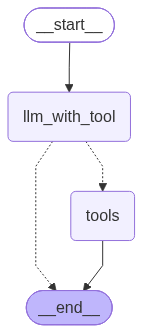

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage
from langchain_tavily import TavilySearch
from langchain.tools import tool

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# create llm or agent 
llm = init_chat_model(
    "openrouter/free",
    model_provider="openrouter"
)


# create state 
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# create tool
tavily_tool = TavilySearch(max_results=3)

@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tools = [tavily_tool, isPrime_tool]


# llm with tools node
def llm_with_tool_node(state: State):
    llm_with_tool = llm.bind_tools(tools)
    resp = {"messages": [llm_with_tool.invoke(state["messages"])]}
    return resp

# create graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_edge("llm_with_tool", "tools")
graph_builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
graph_builder.add_edge("tools", END)
graph = graph_builder.compile()
graph

In [16]:
graph.invoke({
    "messages": "what is the current rate of gold"
})

RateLimitError: Error code: 429 - {'error': {'message': "Request too large for model `qwen/qwen3.6-27b` in organization `org_01m0fnmyjte36bwmy5y9ytzy57` service tier `on_demand` on output tokens per minute (OTPM): Limit 1000, Requested 2048. The request's expected output tokens exceed the enforced limit; reduce max_tokens (or the request's expected output) and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing", 'type': 'tokens', 'code': 'rate_limit_exceeded'}}